In [11]:

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [12]:
# ---------- 1) Load & clean data ----------
raw_txt = """City\tpopulation (kreisfreistadt)\tkreisfreistadt area\tpopulation density\temployment data (kreisfreistadt)\tdriving license ownership\tnodes\tedges\thex_500\thex_1000\thex_2000\tnetwork density (E/(N*(N-1))\tAverage Betweenness\tMean Edge Centrality
muenchen\t1512491\t310,70\t4868,01\t705609\t832,387\t25036\t53806\t2945\t8533\t38231\t0,000086\t0,004634\t0,000105
augsburg\t301033\t146,85\t2049,94\t129512\t164260\t8723\t19042\t2945\t8533\t54\t0,000250\t0,009449\t0,000195
nuernberg\t523026\t186,44\t2805,33\t230823\t283,033\t12973\t26637\t2945\t8534\t555\t0,000158\t0,007379\t0,000132
ingolstadt\t141029\t133,35\t1057,59\t65283\t84,154\t5321\t12312\t2945\t300\t18\t0,000435\t0,015684\t0,000153
regensburg\t157443\t80,86\t1947,11\t70456\t208,192\t5213\t10617\t2946\t2000\t31\t0,000391\t0,013233\t0,000185
wuerzburg\t127810\t87,60\t1459,02\t55282\t149,762\t5474\t11307\t2946\t3000\t31\t0,000377\t0,011508\t0,000203
aschaffenburg\t72444\t62,45\t1160,03\t30726\t42,137\t3008\t6639\t2946\t30\t6\t0,000734\t0,016015\t0,000268
bamberg\t79935\t54,62\t1463,47\t31376\t142,759\t6609\t13049\t1000\t20\t3\t0,000299\t0,015718\t0,000317
bayreuth\t74506\t66,89\t1113,86\t29152\t110440\t3385\t7335\t2946\t200\t4\t0,000640\t0,018992\t0,000238
erlangen\t116562\t76,96\t1514,58\t52469\t155,374\t4687\t9869\t2946\t50\t18\t0,000449\t0,015376\t0,000196
fuerth\t131433\t63,35\t2074,71\t60143\t68,859\t3278\t6984\t2967\t100\t10\t0,000650\t0,018287\t0,000191
kempten\t70056\t63,28\t1107,08\t30632\t70,074\t2907\t6158\t2967\t50\t3\t0,000729\t0,018252\t0,000259
landshut\t75457\t65,83\t1146,24\t32546\t153,662\t2891\t6534\t2969\t100\t18\t0,000782\t0,022464\t0,000218
rosenheim\t64403\t37,22\t1730,33\t27927\t206,671\t2366\t5466\t20\t6\t3\t0,000977\t0,023865\t0,000302
schweinfurt\t54675\t35,70\t1531,51\t21959\t113,912\t2489\t5286\t600\t10\t3\t0,000854\t0,019796\t0,000314
neuulm\t180425\t515,84\t349,77\t81262\t111,926\t11319\t25581\t2967\t8534\t1012\t0,000200\t0,010726\t0,000069
"""

In [13]:
df = pd.read_csv(io.StringIO(raw_txt), sep="\t")

In [14]:
df

,City,population (kreisfreistadt),kreisfreistadt area,population density,employment data (kreisfreistadt),driving license ownership,nodes,edges,hex_500,hex_1000,hex_2000,network density (E/(N*(N-1)),Average Betweenness,Mean Edge Centrality
0,muenchen,1512491,"310,70","4868,01",705609,"832,387",25036,53806,2945,8533,38231,"0,000086","0,004634","0,000105"
1,augsburg,301033,"146,85","2049,94",129512,164260,8723,19042,2945,8533,54,"0,000250","0,009449","0,000195"
2,nuernberg,523026,"186,44","2805,33",230823,"283,033",12973,26637,2945,8534,555,"0,000158","0,007379","0,000132"
3,ingolstadt,141029,"133,35","1057,59",65283,"84,154",5321,12312,2945,300,18,"0,000435","0,015684","0,000153"
4,regensburg,157443,"80,86","1947,11",70456,"208,192",5213,10617,2946,2000,31,"0,000391","0,013233","0,000185"
5,wuerzburg,127810,"87,60","1459,02",55282,"149,762",5474,11307,2946,3000,31,"0,000377","0,011508","0,000203"
6,aschaffenburg,72444,"62,45","1160,03",30726,"42,137",3008,6639,2946,30,6,"0,000734","0,016015","0,000268"
7,bamberg,79935,"54,62","1463,47",31376,"142,759",6609,13049,1000,20,3,"0,000299","0,015718","0,000317"
8,bayreuth,74506,"66,89","1113,86",29152,110440,3385,7335,2946,200,4,"0,000640","0,018992","0,000238"
9,erlangen,116562,"76,96","1514,58",52469,"155,374",4687,9869,2946,50,18,"0,000449","0,015376","0,000196"


In [15]:
# Clean column names -> snake_case, remove punctuation
def clean_name(s):
    s = s.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]", "", s)
    return s

df.columns = [clean_name(c) for c in df.columns]


In [16]:
df

,city,population_kreisfreistadt,kreisfreistadt_area,population_density,employment_data_kreisfreistadt,driving_license_ownership,nodes,edges,hex_500,hex_1000,hex_2000,network_density_enn1,average_betweenness,mean_edge_centrality
0,muenchen,1512491,"310,70","4868,01",705609,"832,387",25036,53806,2945,8533,38231,"0,000086","0,004634","0,000105"
1,augsburg,301033,"146,85","2049,94",129512,164260,8723,19042,2945,8533,54,"0,000250","0,009449","0,000195"
2,nuernberg,523026,"186,44","2805,33",230823,"283,033",12973,26637,2945,8534,555,"0,000158","0,007379","0,000132"
3,ingolstadt,141029,"133,35","1057,59",65283,"84,154",5321,12312,2945,300,18,"0,000435","0,015684","0,000153"
4,regensburg,157443,"80,86","1947,11",70456,"208,192",5213,10617,2946,2000,31,"0,000391","0,013233","0,000185"
5,wuerzburg,127810,"87,60","1459,02",55282,"149,762",5474,11307,2946,3000,31,"0,000377","0,011508","0,000203"
6,aschaffenburg,72444,"62,45","1160,03",30726,"42,137",3008,6639,2946,30,6,"0,000734","0,016015","0,000268"
7,bamberg,79935,"54,62","1463,47",31376,"142,759",6609,13049,1000,20,3,"0,000299","0,015718","0,000317"
8,bayreuth,74506,"66,89","1113,86",29152,110440,3385,7335,2946,200,4,"0,000640","0,018992","0,000238"
9,erlangen,116562,"76,96","1514,58",52469,"155,374",4687,9869,2946,50,18,"0,000449","0,015376","0,000196"


In [17]:
# Columns with decimal commas -> convert to float with dot
num_cols = [c for c in df.columns if c != "city"]

for c in num_cols:
    if c == "driving_license_ownership":
        # Remove commas completely (e.g. "832,387" -> "832387")
        df[c] = df[c].astype(str).str.replace(",", "", regex=False)
    else:
        # Convert decimal commas to dots (e.g. "310,70" -> "310.70")
        df[c] = df[c].astype(str).str.replace(".", "", regex=False)  # remove thousand separators if any
        df[c] = df[c].str.replace(",", ".", regex=False)             # decimal comma -> dot
    df[c] = pd.to_numeric(df[c], errors="coerce")


In [18]:
df

,city,population_kreisfreistadt,kreisfreistadt_area,population_density,employment_data_kreisfreistadt,driving_license_ownership,nodes,edges,hex_500,hex_1000,hex_2000,network_density_enn1,average_betweenness,mean_edge_centrality
0,muenchen,1512491,310.70,4868.01,705609,832387,25036,53806,2945,8533,38231,0.000086,0.004634,0.000105
1,augsburg,301033,146.85,2049.94,129512,164260,8723,19042,2945,8533,54,0.000250,0.009449,0.000195
2,nuernberg,523026,186.44,2805.33,230823,283033,12973,26637,2945,8534,555,0.000158,0.007379,0.000132
3,ingolstadt,141029,133.35,1057.59,65283,84154,5321,12312,2945,300,18,0.000435,0.015684,0.000153
4,regensburg,157443,80.86,1947.11,70456,208192,5213,10617,2946,2000,31,0.000391,0.013233,0.000185
5,wuerzburg,127810,87.60,1459.02,55282,149762,5474,11307,2946,3000,31,0.000377,0.011508,0.000203
6,aschaffenburg,72444,62.45,1160.03,30726,42137,3008,6639,2946,30,6,0.000734,0.016015,0.000268
7,bamberg,79935,54.62,1463.47,31376,142759,6609,13049,1000,20,3,0.000299,0.015718,0.000317
8,bayreuth,74506,66.89,1113.86,29152,110440,3385,7335,2946,200,4,0.000640,0.018992,0.000238
9,erlangen,116562,76.96,1514.58,52469,155374,4687,9869,2946,50,18,0.000449,0.015376,0.000196


In [19]:
# ---------- 2) Feature selection & scaling ----------
features = [c for c in df.columns if c != "city"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# ---------- 3) K-Means: elbow + silhouette, pick best k ----------
inertias, sils = {}, {}
best_k, best_sil = None, -1

K_RANGE = range(2, 7)  # try 2..6 clusters
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    sils[k] = sil
    if sil > best_sil:
        best_sil, best_k = sil, k

print("K-Means inertias:", inertias)
print("K-Means silhouettes:", sils)
print(f"Chosen K (by silhouette): {best_k} (score={best_sil:.3f})\n")

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

K-Means inertias: {2: 171.9717977989771, 3: 72.8739617138725, 4: 31.408038681966218, 5: 30.685110519697226, 6: 14.447651582799988}
K-Means silhouettes: {2: 0.1888602018884238, 3: 0.31646202829195336, 4: 0.3958296516779727, 5: 0.2668048479850554, 6: 0.33566037510183777}
Chosen K (by silhouette): 4 (score=0.396)



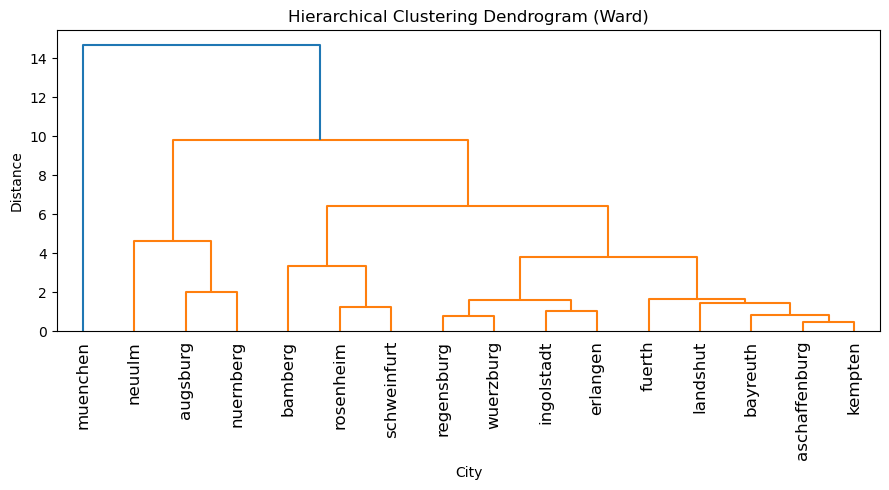

In [22]:
# ---------- 4) Agglomerative (Ward) ----------
# Use same k as K-Means for comparison (you can change)
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["agg_cluster"] = agg.fit_predict(X_scaled)

# Dendrogram (Ward linkage on scaled data)
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(9, 5))
dendrogram(Z, labels=df["city"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("City")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [23]:
# ---------- 5) DBSCAN: quick grid over eps, pick "reasonable" result ----------
# Heuristic: try eps from 0.8 to 2.0 in scaled space; min_samples from 2..4
best_db = None
best_summary = None

def summarize(labels):
    n_noise = np.sum(labels == -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, n_noise

for eps in np.linspace(0.8, 2.0, 7):
    for ms in (2, 3, 4):
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters, n_noise = summarize(labels)
        # prefer between 2 and 6 clusters with limited noise
        if 2 <= n_clusters <= 6 and n_noise <= 4:
            best_db = db
            best_summary = (eps, ms, n_clusters, n_noise)
            break
    if best_db:
        break

if best_db:
    df["dbscan_cluster"] = best_db.fit_predict(X_scaled)
    eps, ms, ncl, nn = best_summary
    print(f"DBSCAN chosen: eps={eps:.2f}, min_samples={ms} -> clusters={ncl}, noise={nn}\n")
else:
    # fallback
    db = DBSCAN(eps=1.2, min_samples=3)
    df["dbscan_cluster"] = db.fit_predict(X_scaled)
    print("DBSCAN used default eps=1.2, min_samples=3 (tune as needed)\n")

DBSCAN chosen: eps=2.00, min_samples=2 -> clusters=3, noise=3



In [24]:
# ---------- 6) Results ----------
show_cols = ["city", "kmeans_cluster", "agg_cluster", "dbscan_cluster"]
print(df[show_cols].sort_values(["kmeans_cluster", "city"]).to_string(index=False))

         city  kmeans_cluster  agg_cluster  dbscan_cluster
     augsburg               0            0               0
       neuulm               0            0              -1
    nuernberg               0            0               0
      bamberg               1            1              -1
    rosenheim               1            1               2
  schweinfurt               1            1               2
     muenchen               2            3              -1
aschaffenburg               3            2               1
     bayreuth               3            2               1
     erlangen               3            2               1
       fuerth               3            2               1
   ingolstadt               3            2               1
      kempten               3            2               1
     landshut               3            2               1
   regensburg               3            2               1
    wuerzburg               3            2              

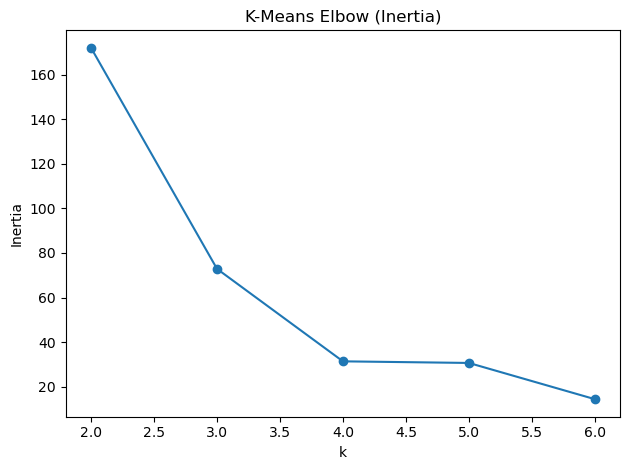

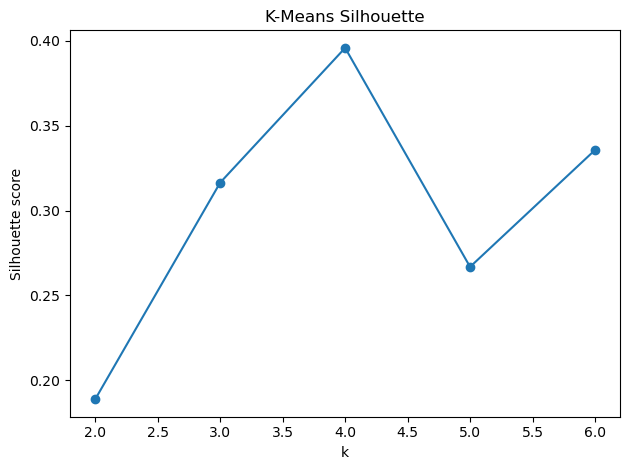


K-Means cluster centers (approx, original scale):
 kmeans_cluster  population_kreisfreistadt  kreisfreistadt_area  population_density  employment_data_kreisfreistadt  driving_license_ownership     nodes     edges  hex_500  hex_1000  hex_2000  network_density_enn1  average_betweenness  mean_edge_centrality
              0                 334828.000              283.043            1735.013                      147199.000                 186406.333 11005.000 23753.333 2952.333  8533.667   540.333                 0.000                0.009                   0.0
              1                  66337.667               42.513            1575.103                       27087.333                 154447.333  3821.333  7933.667  540.000    12.000     3.000                 0.001                0.020                   0.0
              2                1512491.000              310.700            4868.010                      705609.000                 832387.000 25036.000 53806.000 2945.000  8533.

In [25]:
# ---------- 7) Optional: plot elbow & silhouette for K-Means ----------
plt.figure()
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.title("K-Means Elbow (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(list(sils.keys()), list(sils.values()), marker="o")
plt.title("K-Means Silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

# ---------- 8) (Nice to have) peek at cluster centers in original scale ----------
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_unscaled, columns=features)
centers_df.insert(0, "kmeans_cluster", range(best_k))
print("\nK-Means cluster centers (approx, original scale):")
print(centers_df.round(3).to_string(index=False))

In [27]:
# ---------- Summaries for each method ----------

print("\n=== K-Means Clusters ===")
for cl in sorted(df["kmeans_cluster"].unique()):
    group = df.loc[df["kmeans_cluster"] == cl, "city"].tolist()
    print(f"Cluster {cl}: {group}")

print("\n=== Hierarchical (Agglomerative) Clusters ===")
for cl in sorted(df["agg_cluster"].unique()):
    group = df.loc[df["agg_cluster"] == cl, "city"].tolist()
    print(f"Cluster {cl}: {group}")

print("\n=== DBSCAN Clusters ===")
for cl in sorted(df["dbscan_cluster"].unique()):
    group = df.loc[df["dbscan_cluster"] == cl, "city"].tolist()
    if cl == -1:
        print(f"Noise (outliers): {group}")
    else:
        print(f"Cluster {cl}: {group}")



=== K-Means Clusters ===
Cluster 0: ['augsburg', 'nuernberg', 'neuulm']
Cluster 1: ['bamberg', 'rosenheim', 'schweinfurt']
Cluster 2: ['muenchen']
Cluster 3: ['ingolstadt', 'regensburg', 'wuerzburg', 'aschaffenburg', 'bayreuth', 'erlangen', 'fuerth', 'kempten', 'landshut']

=== Hierarchical (Agglomerative) Clusters ===
Cluster 0: ['augsburg', 'nuernberg', 'neuulm']
Cluster 1: ['bamberg', 'rosenheim', 'schweinfurt']
Cluster 2: ['ingolstadt', 'regensburg', 'wuerzburg', 'aschaffenburg', 'bayreuth', 'erlangen', 'fuerth', 'kempten', 'landshut']
Cluster 3: ['muenchen']

=== DBSCAN Clusters ===
Noise (outliers): ['muenchen', 'bamberg', 'neuulm']
Cluster 0: ['augsburg', 'nuernberg']
Cluster 1: ['ingolstadt', 'regensburg', 'wuerzburg', 'aschaffenburg', 'bayreuth', 'erlangen', 'fuerth', 'kempten', 'landshut']
Cluster 2: ['rosenheim', 'schweinfurt']
